In [1]:
import os
import sys
current_directory = os.getcwd()
upper_directory = os.path.abspath(os.path.join(current_directory, ".."))
sys.path.append(upper_directory)


## ================================================================= ##

import torch
import numpy as np
import yaml
import matplotlib.pyplot as plt

from dataset import ERA5_Dynamics_Dataset, ERA5_DA_Dataset
from model.ERA5_model.ERA5_model import ERA5_C_FORWARD, ERA5_C_INVERSE
from utils import dict2namespace

from var_opt.Tensor_Var import Tensor_Var

In [2]:
working_dir = "../training_scripts/ERA5"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("[INFO] Using {} device".format(device))
print("[INFO] ", torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU')

config_path = os.path.join(working_dir, 'config.yaml')
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
config = dict2namespace(config)

[INFO] Using cuda device
[INFO]  _CudaDeviceProperties(name='NVIDIA GeForce RTX 4090', major=8, minor=9, total_memory=24195MB, multi_processor_count=128)


In [3]:
# Load models
forward_model = ERA5_C_FORWARD()
forward_model.load_state_dict(torch.load(working_dir + '/model_weights/forward_model.pt', map_location="cpu"))
forward_model.C_forward = torch.load(working_dir + '/model_weights/C_forward.pt', map_location=device)
forward_model.to(device)

/tmp/ipykernel_2132245/3516303963.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  forward_model.load_state_dict(torch.load(working_dir + '/model_weights/forward_model.pt

ERA5_C_FORWARD(
  (K_S): ERA5_K_S(
    (Conv2D_size5_1): Conv2d(5, 32, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (Conv2D_size5_2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (Conv2D_size3_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (Conv2D_size3_2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (Conv2D_size3_3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (pooling): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (relu): ReLU()
    (linear): Linear(in_features=2048, out_features=512, bias=True)
  )
  (K_S_preimage): ERA5_K_S_preimage(
    (linear): Linear(in_features=512, out_features=2048, bias=True)
    (ConvTranspose2D_size3_1): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (ConvTranspose2D_size3_2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

In [4]:
max_val = np.load("../data/ERA5_data/max_val.npy")
min_val = np.load("../data/ERA5_data/min_val.npy")
state_data_file_path = "../data/ERA5_data/test_seq_state.h5"
obs_data_file_path = "../data/ERA5_data/test_seq_obs.h5"
DA_dataset = ERA5_DA_Dataset(state_data_file_path, 
                             obs_data_file_path, 
                             history_len=config.history_len,
                             min_val=min_val,
                             max_val=max_val)

In [5]:
inv_obs_model = ERA5_C_INVERSE()
inv_obs_model.load_state_dict(torch.load(working_dir + '/model_weights/inverse_model.pt'))
inv_obs_model.to(device)

# Load error covariance matrices
try:
    Q = torch.load(working_dir + '/' + 'Q.pt', map_location="cpu")
    R = torch.load(working_dir + '/' + 'R.pt', map_location="cpu")
    B = torch.load(working_dir + '/' + 'B.pt', map_location="cpu")
except:
    hidden_dim = forward_model.K_S.hidden_dims[-1]
    B = np.eye(hidden_dim) * 0.1
    R = np.eye(hidden_dim) 
    Q = np.eye(hidden_dim) * 0.1

DA_Tensor_Var = Tensor_Var(n_state=(5, 64, 32),
                           n_obs=(5, 64, 32),
                           forward_model=forward_model, 
                           observation_model=inv_obs_model, 
                           B=B,
                           Q=Q,
                           R=R)

[INFO] Freezing K_S
[INFO] Freezing K_S_preimage


/tmp/ipykernel_2132245/3128849447.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inv_obs_model.load_state_dict(torch.load(working_dir + '/model_weights/inverse_model.pt

In [6]:
ass_w = 3 # assimilation window 
ass_T = ass_w * 20

num_mc = 10 # number of repeated experiments

In [7]:
z_b = torch.load(working_dir + "/model_weights/z_b.pt")
weight_matrix = np.load("../data/ERA5_data/weight_matrix.npy")
weight_matrix = np.repeat(weight_matrix[np.newaxis,:,:], repeats=5, axis=0)

for j in range(num_mc):
    print("Sample: ", j)
    test_seq_obs = []
    test_seq_state = []
    s = np.random.randint(500, 1000)
    for k in range(ass_T):
        test_seq_state.append(DA_dataset[s+k][1])
        test_seq_obs.append(DA_dataset[s+k][0])

    test_seq_state = torch.stack(test_seq_state)

    test_seq_obs = torch.stack(test_seq_obs).to(device)   
    traj_estimation, evaluation_time = DA_Tensor_Var.perform_4DVar_ERA5(test_seq_obs,
                                                                        z_b,
                                                                        ass_w,
                                                                        ass_T,
                                                                        "cuda")
    error = []
    for i in range(ass_T):
        traj_est_de = traj_estimation[i]
        traj_true_de = test_seq_state[i].numpy()
        norm = np.linalg.norm(((traj_true_de)*weight_matrix).reshape(5,-1), axis=1)
        relative_error = np.linalg.norm( ((traj_est_de - traj_true_de)*weight_matrix).reshape(5,-1), axis=1 ) / norm
        error.append(relative_error)
    error = np.array(error)
    print("Weighted NRMSE Relative Error, sample {}: ".format(j), np.mean(error, axis=0))
    print("Evaulation time: ", evaluation_time)

/tmp/ipykernel_2132245/3684078534.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  z_b = torch.load(working_dir + "/model_weights/z_b.pt")


Sample:  0


100%|██████████| 20/20 [00:13<00:00,  1.52it/s]


Weighted NRMSE Relative Error, sample 0:  [0.00842443 0.01266801 0.04424052 0.03144517 0.03119928]
Evaulation time:  13.18603515625
Sample:  1


100%|██████████| 20/20 [00:12<00:00,  1.56it/s]


...

Weighted NRMSE Relative Error, sample 7:  [0.00823175 0.01232455 0.04528757 0.03079511 0.03088339]
Evaulation time:  12.668306350708008
Sample:  8


100%|██████████| 20/20 [00:12<00:00,  1.55it/s]


Weighted NRMSE Relative Error, sample 8:  [0.00863691 0.01297512 0.04410461 0.03151193 0.03153133]
Evaulation time:  12.881758451461792
Sample:  9


100%|██████████| 20/20 [00:12<00:00,  1.56it/s]

Weighted NRMSE Relative Error, sample 9:  [0.00825447 0.01203762 0.04611836 0.03039711 0.0302821 ]
Evaulation time:  12.831604480743408


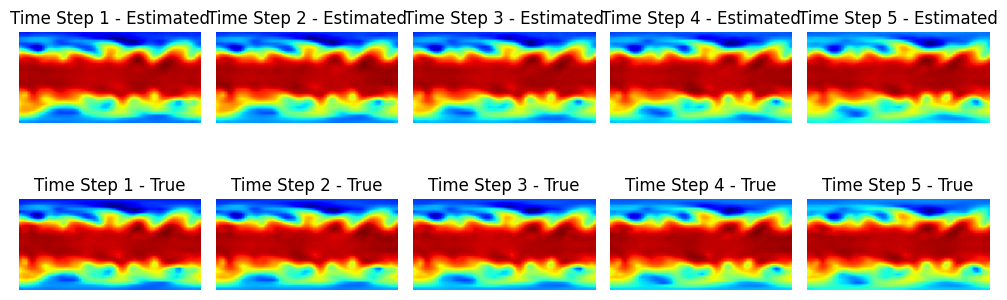

In [8]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    ax[0, i].imshow(traj_estimation[i][0,...].T, cmap='jet')
    ax[1, i].imshow(test_seq_state[i][0,...].numpy().T, cmap='jet')
    ax[0, i].axis('off')
    ax[1, i].axis('off')
    ax[0, i].set_title(f"Time Step {i+1} - Estimated")
    ax[1, i].set_title(f"Time Step {i+1} - True")
plt.tight_layout()

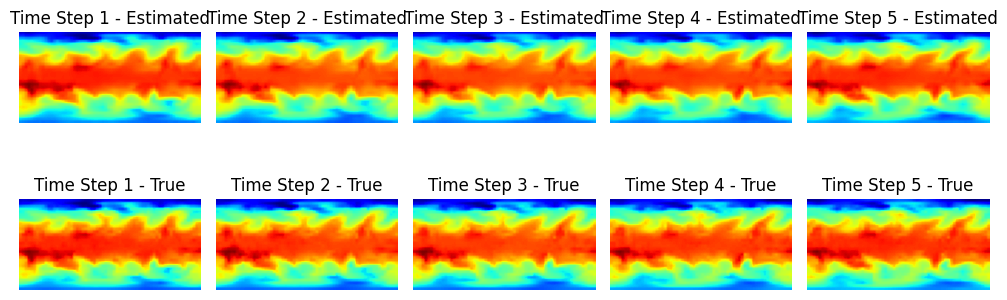

In [9]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    ax[0, i].imshow(traj_estimation[i][1,...].T, cmap='jet')
    ax[1, i].imshow(test_seq_state[i][1,...].numpy().T, cmap='jet')
    ax[0, i].axis('off')
    ax[1, i].axis('off')
    ax[0, i].set_title(f"Time Step {i+1} - Estimated")
    ax[1, i].set_title(f"Time Step {i+1} - True")
plt.tight_layout()

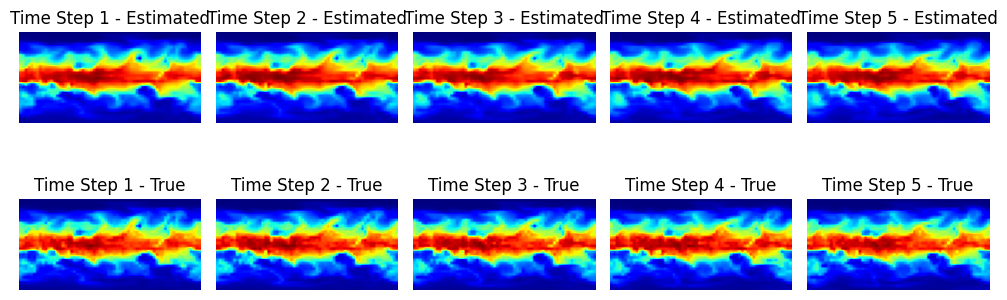

In [10]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    ax[0, i].imshow(traj_estimation[i][2,...].T, cmap='jet')
    ax[1, i].imshow(test_seq_state[i][2,...].numpy().T, cmap='jet')
    ax[0, i].axis('off')
    ax[1, i].axis('off')
    ax[0, i].set_title(f"Time Step {i+1} - Estimated")
    ax[1, i].set_title(f"Time Step {i+1} - True")
plt.tight_layout()

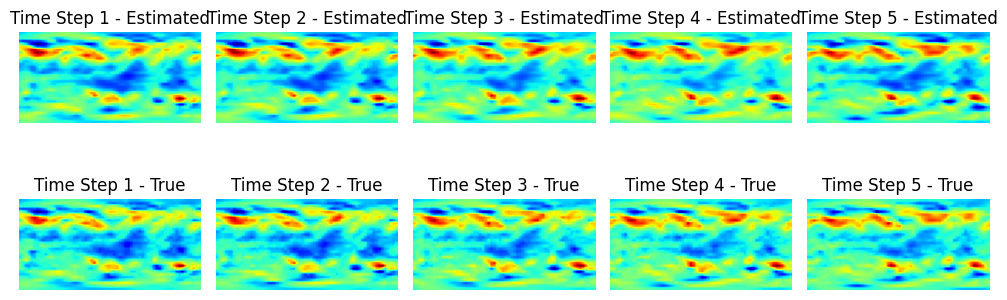

In [11]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    ax[0, i].imshow(traj_estimation[i][3,...].T, cmap='jet')
    ax[1, i].imshow(test_seq_state[i][3,...].numpy().T, cmap='jet')
    ax[0, i].axis('off')
    ax[1, i].axis('off')
    ax[0, i].set_title(f"Time Step {i+1} - Estimated")
    ax[1, i].set_title(f"Time Step {i+1} - True")
plt.tight_layout()

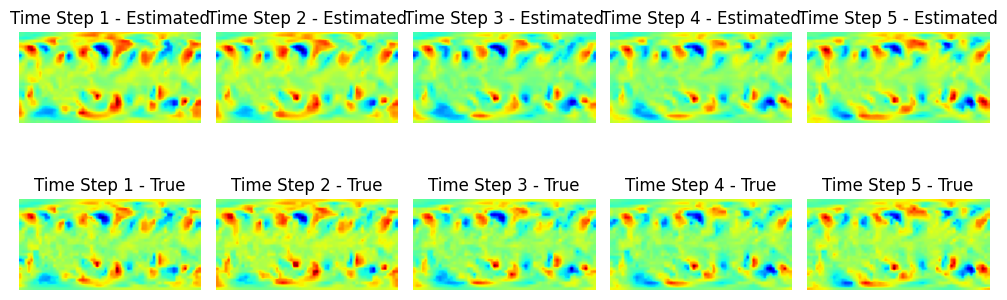

In [12]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    ax[0, i].imshow(traj_estimation[i][4,...].T, cmap='jet')
    ax[1, i].imshow(test_seq_state[i][4,...].numpy().T, cmap='jet')
    ax[0, i].axis('off')
    ax[1, i].axis('off')
    ax[0, i].set_title(f"Time Step {i+1} - Estimated")
    ax[1, i].set_title(f"Time Step {i+1} - True")
plt.tight_layout()